In [20]:
import numpy as np

# Yeast chromosome lengths from Duan et al. (bp)
chrom_lengths_yeast = np.array([
    230_218, 813_184, 316_620, 1_531_933,
    576_874, 270_161, 1_090_940, 562_643,
    439_888, 745_751, 666_816, 1_078_177,
    924_429, 784_333, 1_091_287, 948_066
], dtype=float)

def simulate(theta,
             resolution=32_000,
             symmetric=True,
             seed=None,
             clip_nonnegative=True):
    """
    16-parameter centromere simulator (Algorithm 1:
    Simulation-based inference of yeast centromeres).

    theta: array-like, shape (16,)
        Centromere positions in bp, one per chromosome.
    resolution: int
        Bin size r in bp (paper: 32,000).
    symmetric: bool
        If True, mirror upper trans blocks (Hi-C-like symmetric map).
    seed: int or None
        RNG seed.
    clip_nonnegative: bool
        Clip negative entries after noise to 0 (sensible for counts).
    """
    rng = np.random.default_rng(seed)
    theta = np.asarray(theta, dtype=float)
    assert theta.shape[0] == 16, "theta must have length 16."

    # Number of bins per chromosome (integer binning at 32 kb)
    # Paper writes li / r; in practice we use floor.
    bins = (chrom_lengths_yeast / resolution).astype(int)
    starts = np.concatenate(([0], np.cumsum(bins[:-1])))
    N = int(bins.sum())

    C = np.zeros((N, N), dtype=float)

    # Global sigma^2 ~ U(0.1, 10), alpha ~ U({1,...,1000})
    sigma2 = rng.uniform(0.1, 10.0)
    sigma = np.sqrt(sigma2)
    alpha = rng.integers(1, 1001)

    # Fill upper trans blocks
    for i in range(16):
        for j in range(i + 1, 16):
            ni = bins[i]
            nj = bins[j]
            if ni == 0 or nj == 0:
                continue

            r0 = starts[i]
            c0 = starts[j]

            x = np.arange(ni)[:, None]
            y = np.arange(nj)[None, :]

            mu_i = theta[i] / resolution
            mu_j = theta[j] / resolution

            dist2 = (x - mu_i) ** 2 + (y - mu_j) ** 2
            Cij = np.exp(-dist2 / (2.0 * sigma ** 2))
            Cij *= alpha

            max_ij = float(Cij.max()) if Cij.size > 0 else 0.0
            if max_ij > 0:
                mu_noise = 0.05 * max_ij
                std_noise = 0.05 * max_ij
                noise = rng.normal(mu_noise, std_noise, size=Cij.shape)
                Cij = Cij + noise

            if clip_nonnegative:
                Cij = np.maximum(Cij, 0.0)

            C[r0:r0 + ni, c0:c0 + nj] = Cij
            if symmetric:
                C[c0:c0 + nj, r0:r0 + ni] = Cij.T

    return C


Bins per chromosome: [ 7 25  9 47 18  8 34 17 13 23 20 33 28 24 34 29]
Total bins N: 369
C shape: (369, 369)
Max |C - C.T|: 0.000e+00
Max deviation of block argmax from (theta_i/r, theta_j/r): 0.73 bins (i direction), 0.96 bins (j direction)
C min: 0.000, C max: 598.896, C mean: 58.171, nonzero frac: 0.815


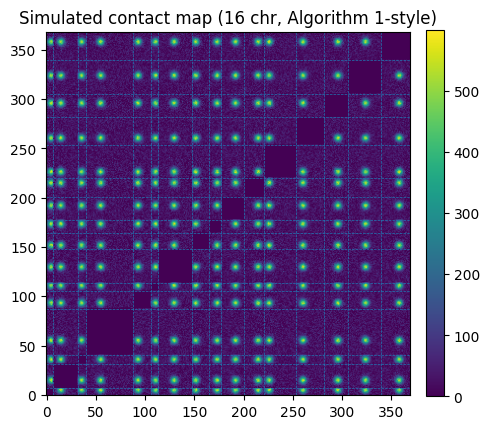

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Reference centromere positions (bp) for yeast
theta_ref_yeast = np.array([
    151_465, 238_207, 114_385, 449_132,
    152_692, 148_510, 497_063, 105_466,
    255_739, 439_294, 438_295, 151_987,
    195_103, 431_359, 557_885, 565_000
], dtype=float)

def validate(theta=None, resolution=32_000, seed=0, make_plot=True):
    if theta is None:
        theta = theta_ref_yeast

    C = simulate(theta, resolution=resolution, symmetric=True, seed=seed)

    bins = (chrom_lengths_yeast / resolution).astype(int)
    N_expected = int(bins.sum())
    starts = np.concatenate(([0], np.cumsum(bins[:-1])))

    # 1. Shape check
    print(f"Bins per chromosome: {bins}")
    print(f"Total bins N: {N_expected}")
    print(f"C shape: {C.shape}")

    # 2. Symmetry check
    sym_err = np.max(np.abs(C - C.T))
    print(f"Max |C - C.T|: {sym_err:.3e}")

    # 3. Peak-location sanity
    max_devs = []
    for i in range(3):          # just check first few
        for j in range(i + 1, 4):
            ni, nj = bins[i], bins[j]
            r0, c0 = starts[i], starts[j]
            if ni == 0 or nj == 0:
                continue
            block = C[r0:r0 + ni, c0:c0 + nj]
            if block.size == 0:
                continue

            pi, pj = np.unravel_index(np.argmax(block), block.shape)
            mu_i = theta[i] / resolution
            mu_j = theta[j] / resolution
            dx = abs(pi - mu_i)
            dy = abs(pj - mu_j)
            max_devs.append((dx, dy))

    if max_devs:
        max_dx = max(d[0] for d in max_devs)
        max_dy = max(d[1] for d in max_devs)
        print(
            "Max deviation of block argmax from (theta_i/r, theta_j/r): "
            f"{max_dx:.2f} bins (i direction), {max_dy:.2f} bins (j direction)"
        )

    # 4. Basic stats
    print(
        f"C min: {C.min():.3f}, C max: {C.max():.3f}, "
        f"C mean: {C.mean():.3f}, nonzero frac: {(C > 0).mean():.3f}"
    )

    if make_plot:
        fig, ax = plt.subplots(figsize=(5, 5))
        im = ax.imshow(C, origin="lower")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_title("Simulated contact map (16 chr, Algorithm 1-style)")

        splits = np.cumsum(bins)[:-1]
        for s in splits:
            ax.axhline(s - 0.5, linestyle="--", linewidth=0.5)
            ax.axvline(s - 0.5, linestyle="--", linewidth=0.5)

        plt.tight_layout()
        plt.show()

    return C

# Run once:
C = validate()


In [25]:
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)
from sbi.inference import NPE, simulate_for_sbi
from sbi.utils import BoxUniform


def simulator(theta):
    return simulate(theta)


# inference
# Check prior, return PyTorch prior.
prior, num_parameters, prior_returns_numpy = process_prior(prior)
num_sim = 1000
theta = prior.sample((num_sim,))
# Check simulator, returns PyTorch simulator able to simulate batches.
simulator = process_simulator(simulator, prior, prior_returns_numpy)
theta, x = simulate_for_sbi(simulator, proposal=prior, num_simulations=num_sim)
inference = NPE(prior)
density_estimator = inference.append_simulations(theta, x).train(max_num_epochs=100)
posterior = inference.build_posterior(density_estimator)
inferences.append(posterior)


  0%|          | 0/1000 [00:00<?, ?it/s]

2025-11-10 11:53:17.168635: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-10 11:53:17.911014: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


RuntimeError: Debug hint: The simulated data x has 2 dimensions.
            With default settings, sbi cannot deal with multidimensional simulations.
            Make sure to use an embedding net that reduces the dimensionality, e.g., a
            CNN in case of images, or change the simulator to return one-dimensional x.
            